### Reloading training data

In [2]:
%%time
import os
import json
import numpy as np

SAVE_DIR = "/mnt/scratch/fast0/amaustin/datasets/fife/"
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")

failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
wait_sv = np.load(os.path.join(SAVE_DIR, "wait_sv.npy"), mmap_mode="r")
tr_mask = np.load(os.path.join(SAVE_DIR, "tr_mask.npy"), mmap_mode="r")
te_mask = np.load(os.path.join(SAVE_DIR, "te_mask.npy"), mmap_mode="r")

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"Train split: {tr_mask.sum():,} rows | Test split: {te_mask.sum():,} rows")

Loaded Xmatch (64025075, 46) and Xsub (64025075, 27)
Train split: 48,546,633 rows | Test split: 15,478,442 rows
CPU times: user 58.9 ms, sys: 8.13 ms, total: 67 ms
Wall time: 65 ms


Feature inventory

In [2]:
print(f"Xmatch {Xmatch.shape} -- match-time tasks (Failed, hw_fault, 3-class fault):")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print(f"\nXsub {Xsub.shape} -- submission-time task (wait_time):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail1h_* (leak-free trailing rates, 1h window, self-excluded),")
print("  log_idle_queue_depth (submitted-not-started at submit), log_camp_trail_wait,")
print("  log_*_running (leak-free concurrent-running counts, self-excluded)")
print("targets: Failed (binary) | hw_fault (binary; matched & typed rows) | "
      "fault_type (3-class) | wait_log = log1p(wait s)")

Xmatch (64025075, 46) -- match-time tasks (Failed, hw_fault, 3-class fault):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignId
  [ 6] CampaignStageId
  [ 7] CampaignType
  [ 8] TestLaunch
  [ 9] JobsubGroup
  [10] Image
  [11] BlacklistSites
  [12] MatchSite
  [13] MatchEntry
  [14] MatchQueue
  [15] MatchResource
  [16] MatchCpus
  [17] RequestCpus (std)
  [18] RequestDisk (std)
  [19] RequestMemory (std)
  [20] RequestSlots (std)
  [21] ExecutableSize (std)
  [22] TransferInputMB (std)
  [23] ExpectedLifetime (std)
  [24] TotalSubmitProcs (std)
  [25] CpusProvisioned (std)
  [26] DiskProvisioned (std)
  [27] MemoryProvisioned (std)
  [28] sin_hour@match
  [29] cos_hour@match
  [30] sin_wday@match
  [31] cos_wday@match
  [32] trail15m_site_fail
  [33] trail15m_entry_fail
  [34] trail15m_node_fail
  [35] trail15m_site_hw
  [36] trail15m_node_hw
  [37] trail15m_camp_fail
  [38] trail60m_site_fail
  [39] trail60m_entry_fail
  [40

In [3]:
np.unique(Xmatch[:, XMATCH_COLS.index("CampaignType")])

array([0., 1., 2., 3., 4.], dtype=float32)

#### Experiment setup

In [3]:
# E1: split-protocol decomposition (Delta): random vs temporal on the same features
import psutil

def mem_gb():
    return psutil.Process().memory_info().rss / (1024 ** 3)

# Target vector & population indices
yv = failed
idx = np.arange(len(yv))

# 1. Temporal split indices (Feb-Jun Train vs Jul-Aug Test)
tri_t = np.where(tr_mask)[0]
tei_t = np.where(te_mask)[0]

# 2. Random split indices (same test size, randomly sampled across all data)
rng = np.random.default_rng(0)
perm = rng.permutation(idx)
rte = np.sort(perm[:len(tei_t)])
rtr = np.sort(perm[len(tei_t):])

E1_SPLITS = [("random", rtr, rte), ("temporal", tri_t, tei_t)]

# Storage dicts (accumulate results across individual model cells)
E1_IMP, E1_CM = {}, {}

print(f"E1 splits prepared: Random ({len(rtr):,} train / {len(rte):,} test) | Temporal ({len(tri_t):,} train / {len(tei_t):,} test)")

E1 splits prepared: Random (48,546,633 train / 15,478,442 test) | Temporal (48,546,633 train / 15,478,442 test)


### Failure prediction: XGBoost
Can also be run in the terminal, example: `python -m eval.harness e1 xgboost`

In [ ]:
import importlib
import train.tree
importlib.reload(train.tree)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print("--- Running E1: XGBoost ---")
print("-" * 55)

run_e1_model("xgboost", Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print("-" * 55)
print(f"[mem] Peak RSS: {mem_gb():.2f} GB", flush=True)

## E1 Results

In [5]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances

# Prepare evaluation slice
eval_idx = tei_t[:200000]
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(yv[eval_idx])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    E1_IMP = load_saved_importances(
        models=["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"], 
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval
    )

[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_e1_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_e1_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/fast0/amaustin/models/lightgbm_bin_e1_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/fast0/amaustin/models/lightgbm_bin_e1_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/fast0/amaustin/models/catboost_bin_e1_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/fast0/amaustin/models/catboost_bin_e1_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
[Loaded TabNet Model] tabnet     (random  ) computed feature importances successfully.
[Loaded TabNet Model] tabnet     (temporal) computed feature importances successfully.
[Computed Permutation Imp] saint      (random  ) on cu

#### Feature importance - random split

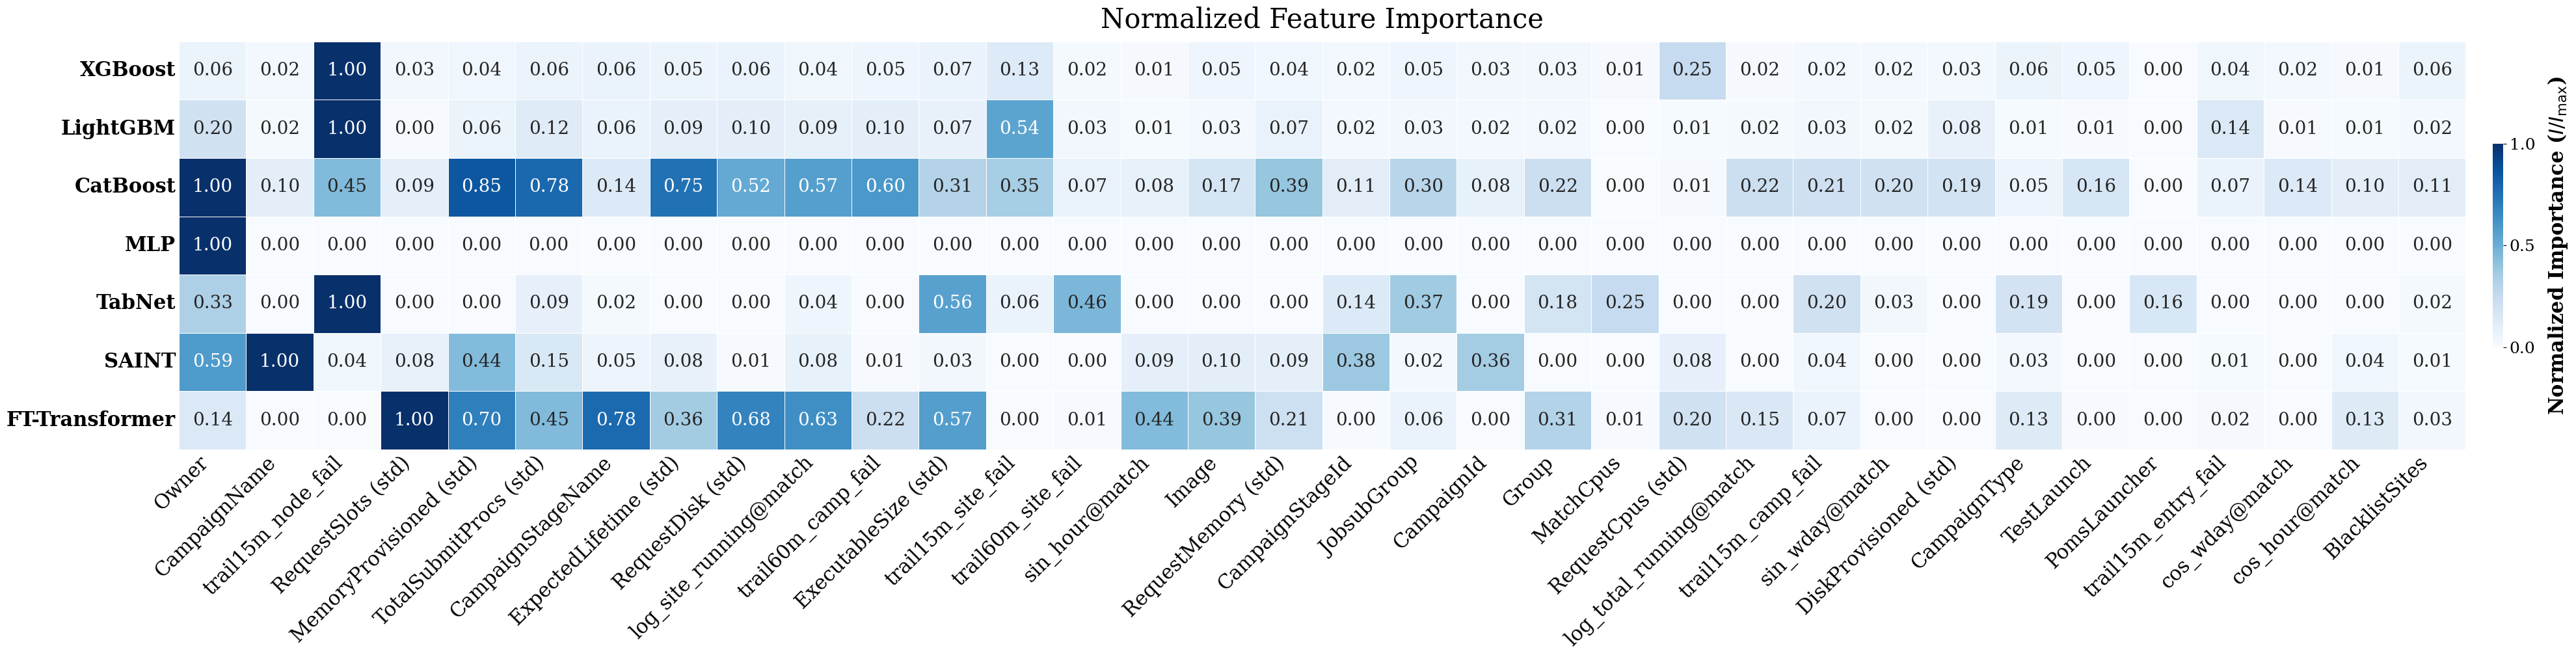

In [17]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import imp_heatmap

df_norm = imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    split_key="random",  
    cmap="Blues",  
)

#### Feature importance - temporal split

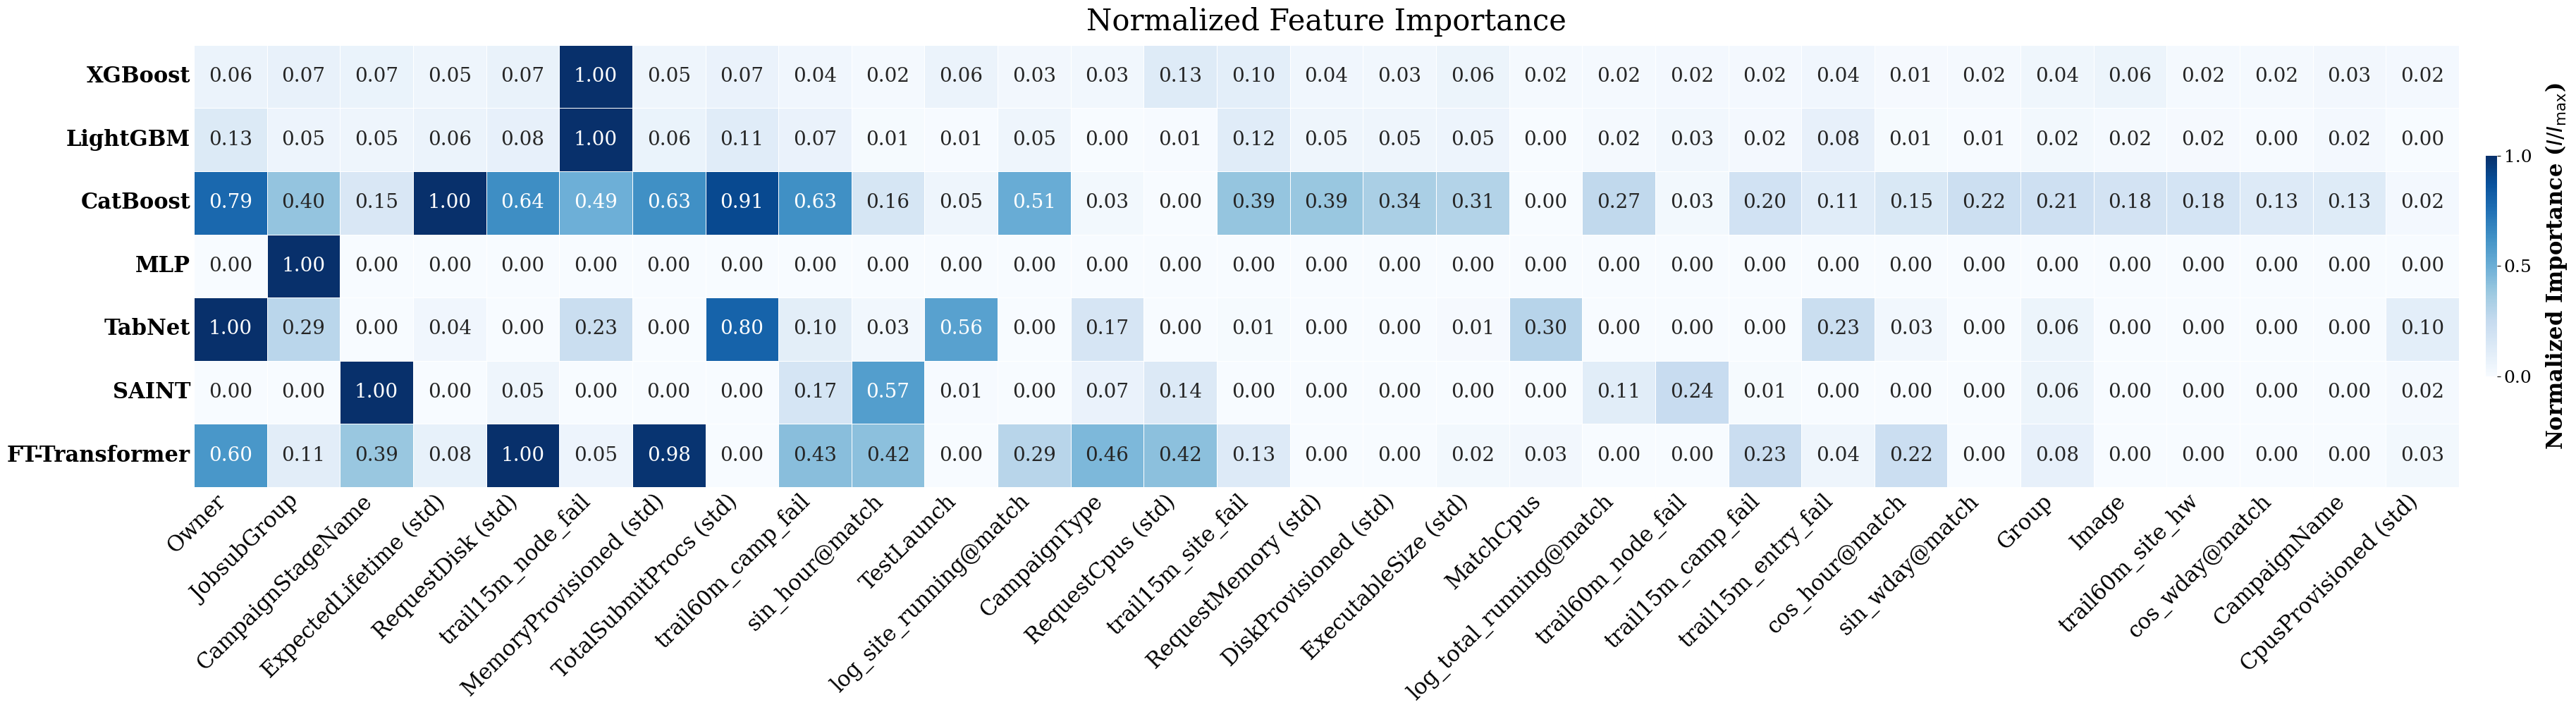

In [15]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import imp_heatmap

df_norm = imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    split_key="temporal",  
    cmap="Blues",  
)

### Feature gain shift (random split -> temporal)

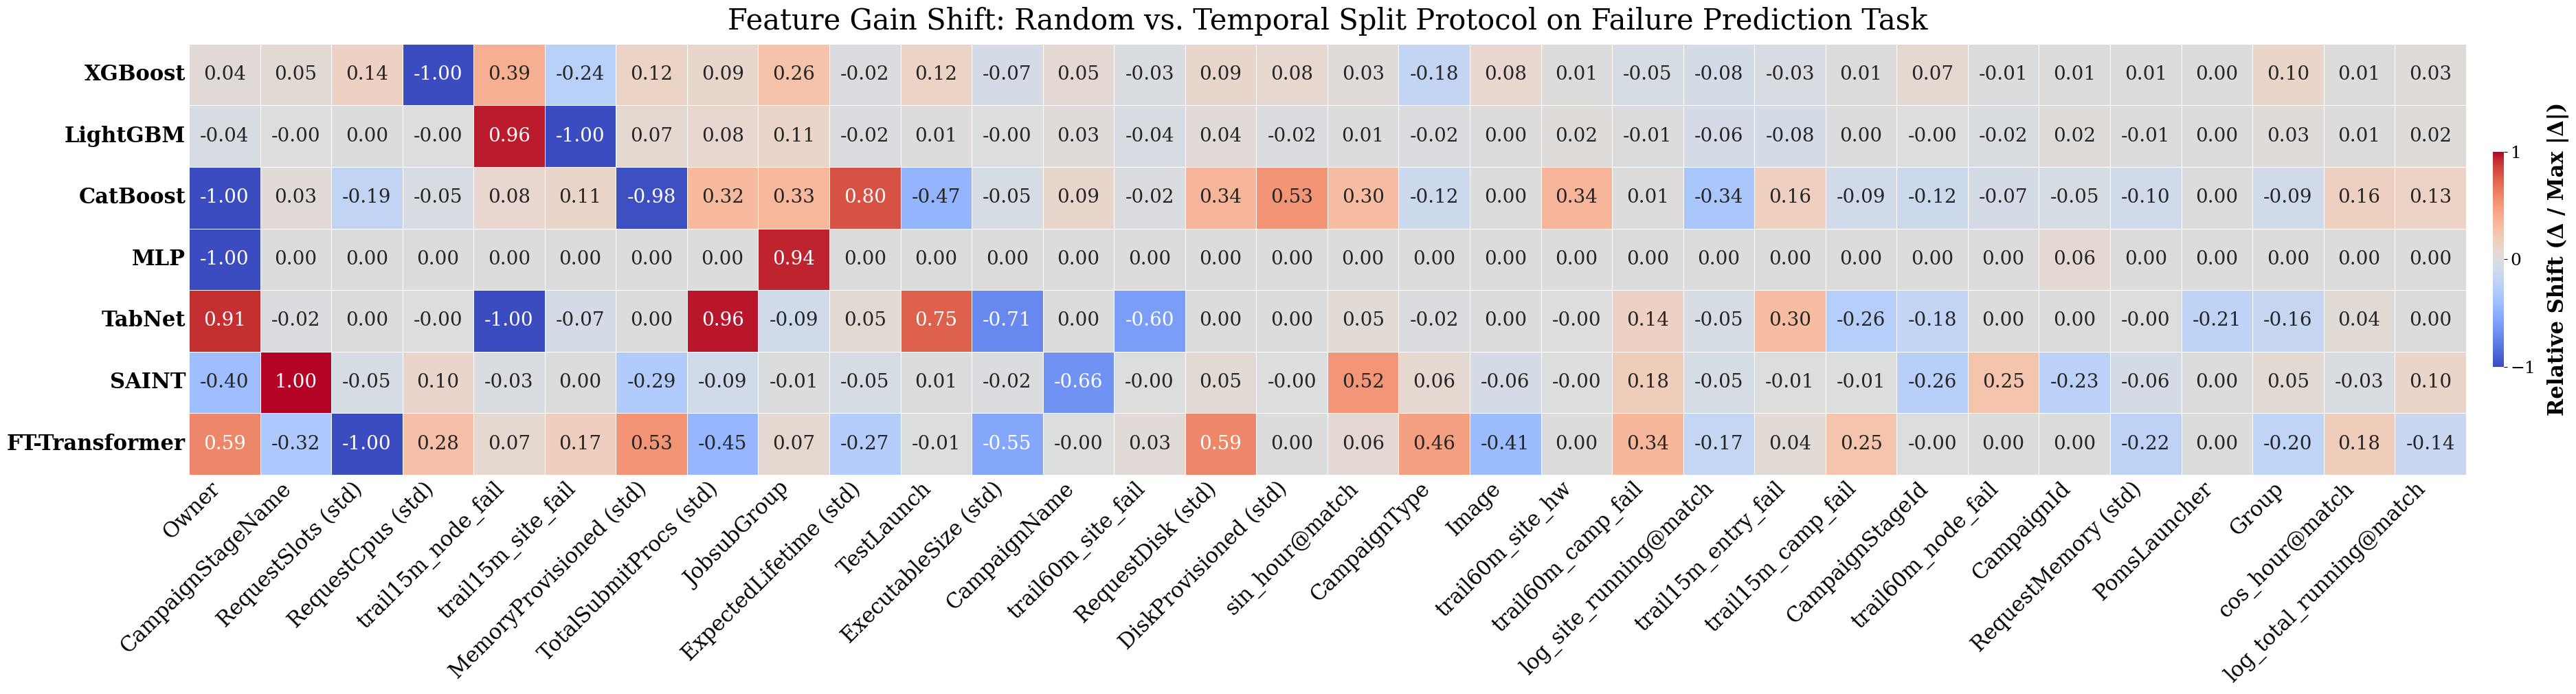

In [6]:
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
)

Running evaluation only (on all models)

In [ ]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_protocol_models

results = evaluate_protocol_models(
    X_all=Xmatch,
    y_all=yv,
    rtr=rtr,  
    rte=rte, 
    tri_t=tri_t, 
    tei_t=tei_t, 
    output_path="output/protocol_eval_results.json",
)
results

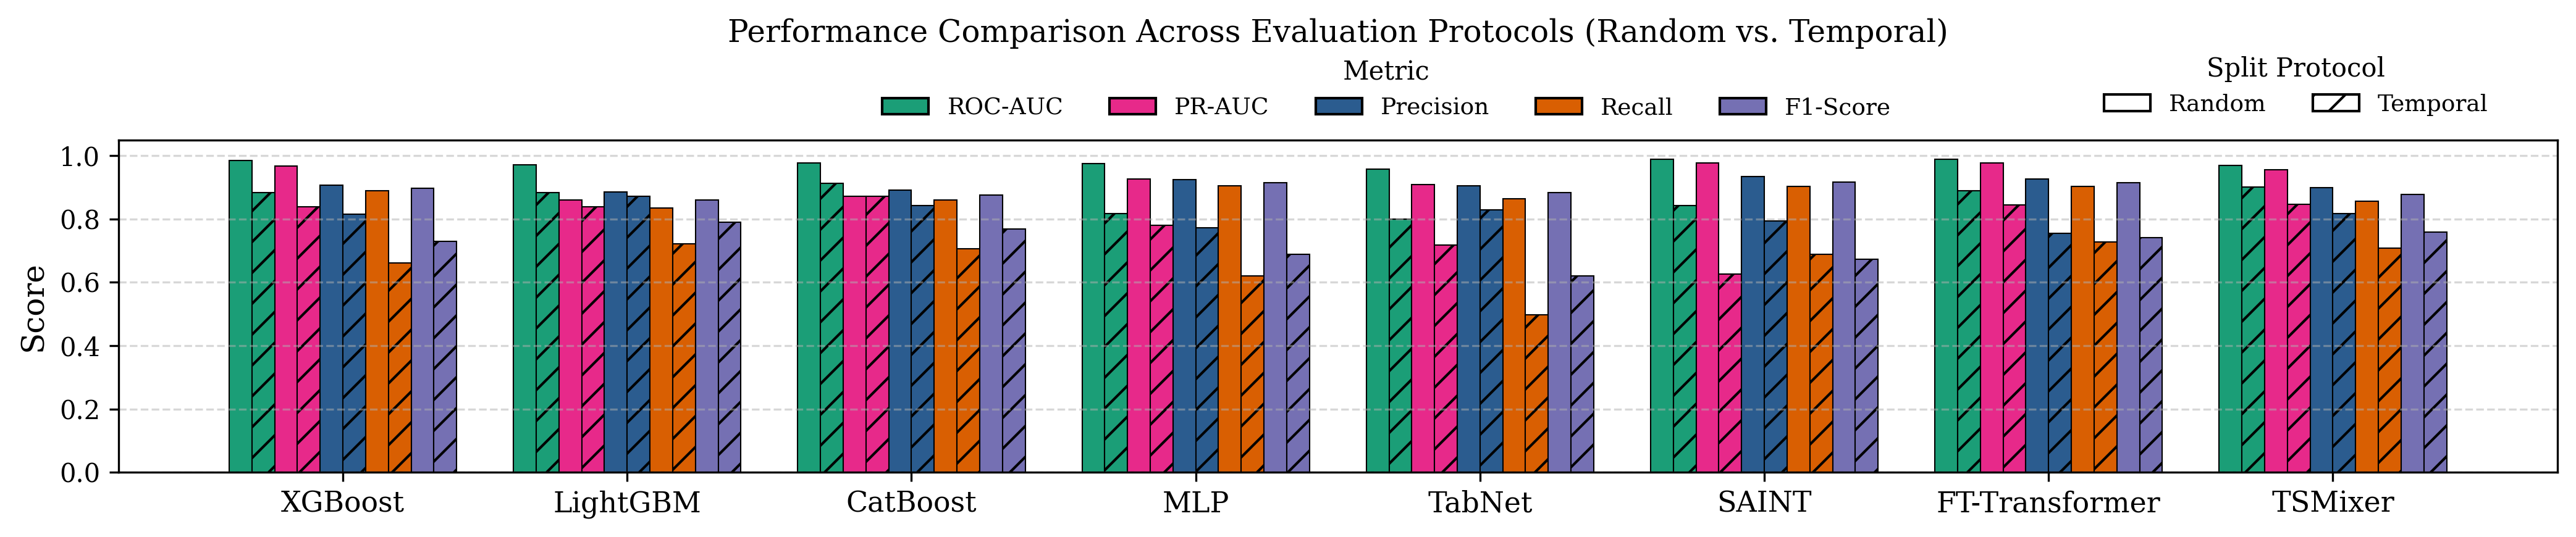

Saved plots to:
  - /opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/output/protocol_ablation_summary.pdf
  - /opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/output/protocol_ablation_summary.png


In [7]:
import json
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

notebook_dir = os.getcwd()
input_path = os.path.join(notebook_dir, "results/protocol_eval_results.json")
with open(input_path, "r") as f:
    results = json.load(f)

# Model key mapping to preserve desired order and clean display names
model_mapping = {
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
    "mlp": "MLP",
    "tabnet": "TabNet",
    "saint": "SAINT",
    "ft": "FT-Transformer",
    "tsmixer": "TSMixer",
}

# Extract available model keys from the new nested JSON structure
model_keys = [k for k in model_mapping.keys() if k in results]
models = [model_mapping[k] for k in model_keys]

# Extract metrics per split from nested structure
roc_r, pr_r, prec_r, rec_r, f1_r = [], [], [], [], []
roc_t, pr_t, prec_t, rec_t, f1_t = [], [], [], [], []

for m_key in model_keys:
    r = results[m_key]["random"]
    t = results[m_key]["temporal"]

    roc_r.append(r["roc_auc"])
    pr_r.append(r["pr_auc"])
    prec_r.append(r["precision"])
    rec_r.append(r["recall"])
    f1_r.append(r["f1"])

    roc_t.append(t["roc_auc"])
    pr_t.append(t["pr_auc"])
    prec_t.append(t["precision"])
    rec_t.append(t["recall"])
    f1_t.append(t["f1"])

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.autolayout": True,
    }
)

fig, ax = plt.subplots(figsize=(14, 3), dpi=300)
x = np.arange(len(models))

# 10 bars per model (5 metrics x 2 splits)
w = 0.08

c_roc = "#1b9e77"
c_pr = "#e7298a"
c_prec = "#2b5c8f"
c_rec = "#d95f02"
c_f1 = "#7570b3"

hatch_random = ""
hatch_temporal = "//"

# Plot all 10 bars with distinct sequential offsets from x - 4.5*w to x + 4.5*w
ax.bar(
    x - 4.5 * w,
    roc_r,
    w,
    color=c_roc,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x - 3.5 * w,
    roc_t,
    w,
    color=c_roc,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x - 2.5 * w,
    pr_r,
    w,
    color=c_pr,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x - 1.5 * w,
    pr_t,
    w,
    color=c_pr,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x - 0.5 * w,
    prec_r,
    w,
    color=c_prec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 0.5 * w,
    prec_t,
    w,
    color=c_prec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x + 1.5 * w,
    rec_r,
    w,
    color=c_rec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 2.5 * w,
    rec_t,
    w,
    color=c_rec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x + 3.5 * w,
    f1_r,
    w,
    color=c_f1,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 4.5 * w,
    f1_t,
    w,
    color=c_f1,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.set_ylabel("Score")
ax.set_title(
    "Performance Comparison Across Evaluation Protocols (Random vs. Temporal)",
    pad=38,
)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0, ha="center")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Dual legends for metrics (color) and splits (texture)
legend_metrics = [
    Patch(facecolor=c_roc, edgecolor="black", label="ROC-AUC"),
    Patch(facecolor=c_pr, edgecolor="black", label="PR-AUC"),
    Patch(facecolor=c_prec, edgecolor="black", label="Precision"),
    Patch(facecolor=c_rec, edgecolor="black", label="Recall"),
    Patch(facecolor=c_f1, edgecolor="black", label="F1-Score"),
]
legend_splits = [
    Patch(facecolor="white", edgecolor="black", label="Random"),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="//",
        label="Temporal",
    ),
]

leg1 = ax.legend(
    handles=legend_metrics,
    title="Metric",
    loc="lower center",
    bbox_to_anchor=(0.52, 1),
    ncol=5,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

ax.add_artist(leg1)
ax.legend(
    handles=legend_splits,
    title="Split Protocol",
    loc="lower right",
    bbox_to_anchor=(0.98, 1.01),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

plt.tight_layout()

os.makedirs(os.path.join(notebook_dir, "output"), exist_ok=True)
pdf_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.pdf")
png_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved plots to:\n  - {pdf_path}\n  - {png_path}")

### E1.5: Feature Ablation on Failed task (temporal split) 
`base -> +cyclical -> +campaign type -> +trailing site/campaign/node status` 